In [13]:

# reading files
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

Displaying


In [14]:

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [16]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [17]:
df.describe(include="O")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [18]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [19]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [20]:
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [21]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

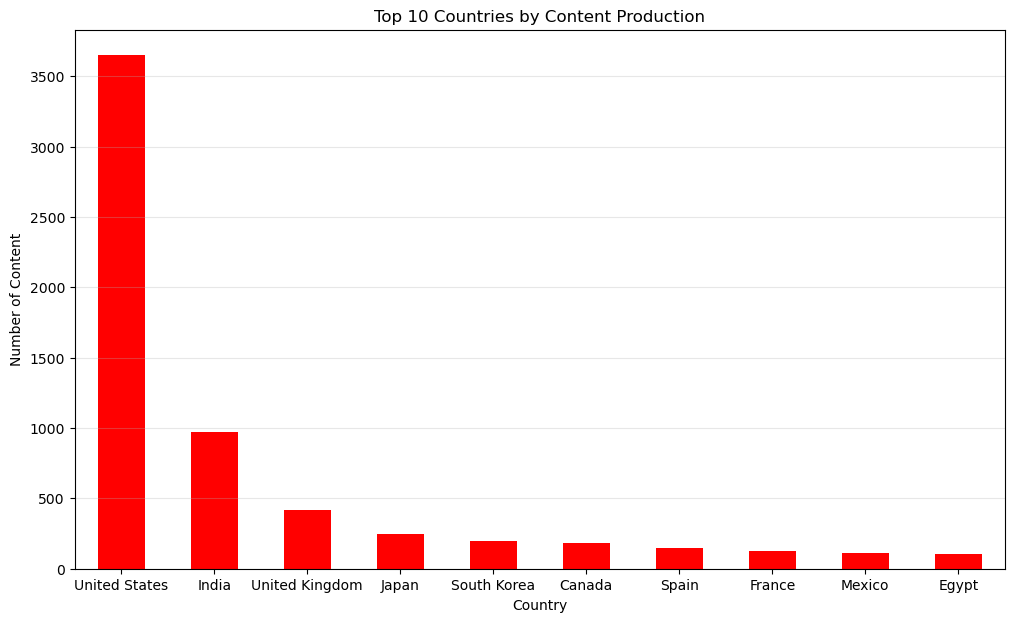

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.figure(figsize=(12, 7))
df['country'].value_counts().head(10).plot(kind='bar' , color="red")
plt.title("Top 10 Countries by Content Production")
plt.xlabel("Country")
plt.ylabel("Number of Content")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

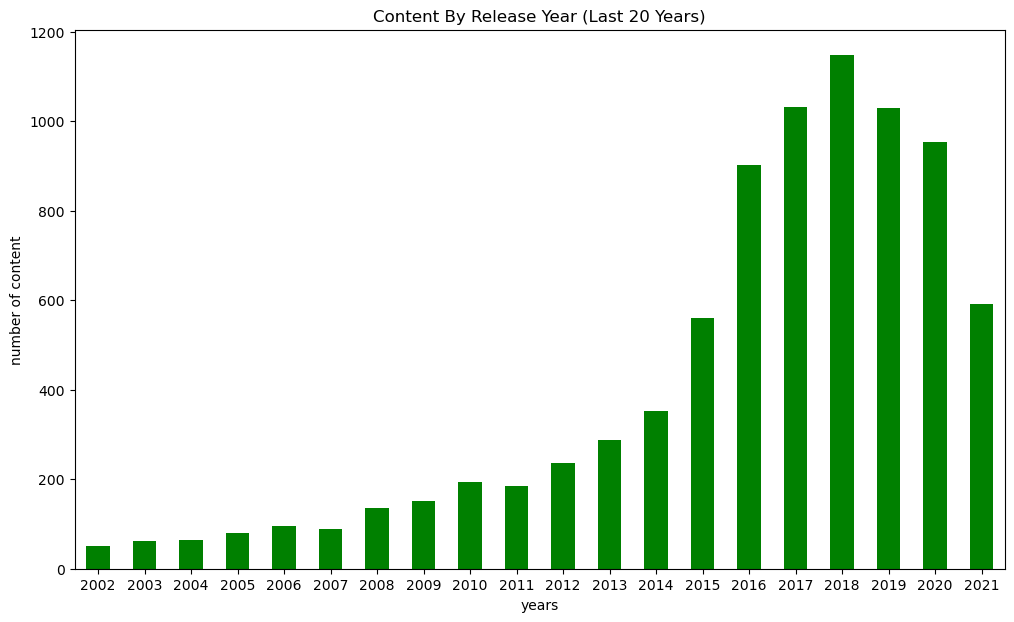

In [24]:
plt.figure(figsize=(12, 7))
df['release_year'].value_counts().sort_index(ascending=True).tail(20).plot(kind='bar' , color="green")
plt.title('Content By Release Year (Last 20 Years)')
plt.ylabel('number of content')
plt.xlabel('years')
plt.xticks(rotation=0)
plt.show()

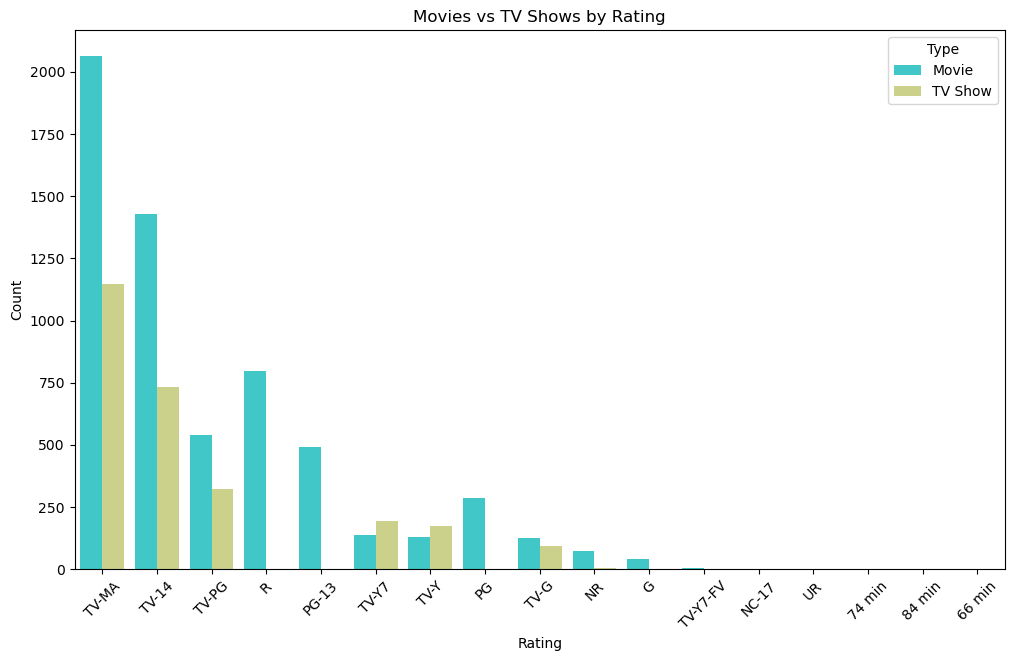

In [25]:
plt.figure(figsize=(12,7))
sns.countplot(x='rating', hue='type', data=df, palette='rainbow', order=df['rating'].value_counts().index)
plt.title('Movies vs TV Shows by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()


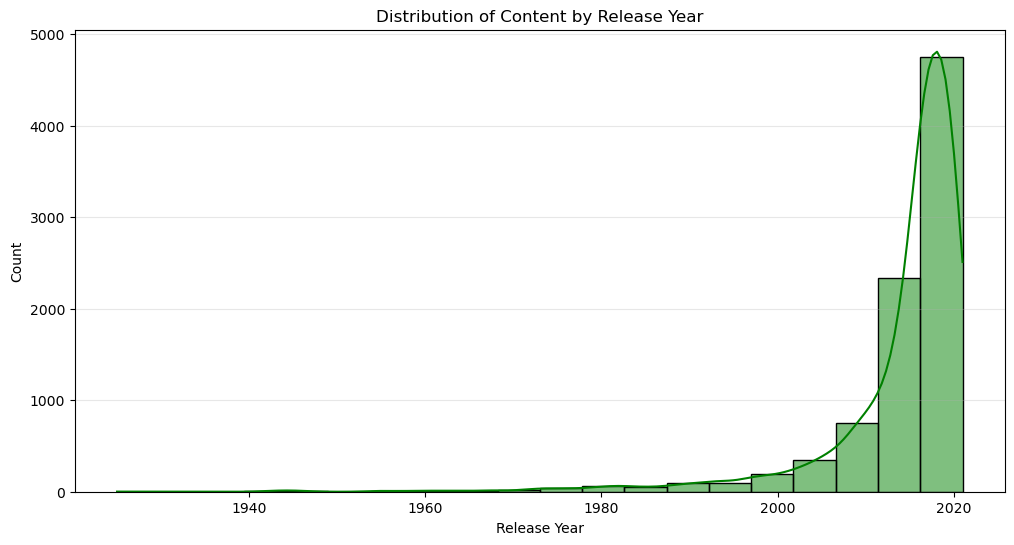

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', bins=20, kde=True, color='green')
plt.title('Distribution of Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [27]:
import plotly.express as px

fig = px.pie(df,names='type',title='Netflix Content by Rating',color_discrete_sequence=['green','red'])
fig.show()

In [28]:
top_countries = df['country'].value_counts().head(10)
fig = px.pie(values=top_countries.values, names=top_countries.index, title='Top 10 Countries by Content Production')
fig.show()

In [29]:
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

fig = px.bar(type_counts, x='type', y='count',
             title='Netflix Content: Movies vs TV Shows',
             labels={'count': 'Number of Titles', 'type': 'Content Type'},
             color='count',
             text='count')

fig.update_layout(width=1000, height=800)
fig.show()